Shape: (500, 6)

First 5 rows:
    Area_sqft  Bedrooms  Location_Score  Distance_from_City_km  \
0       1360         1             4.6                   18.2   
1       4272         1             5.2                    2.6   
2       3592         3             9.5                    4.9   
3        966         5             2.4                   20.4   
4       4926         4             6.3                    7.5   

   Facilities_Score  House_Price_USD  
0               6.5           412097  
1               1.6           568542  
2               5.7           808340  
3               2.4           312879  
4               7.6           856665  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area_sqft              500 non-null    int64  
 1   Bedrooms               500 non-null    int64  
 2   Location_Sc

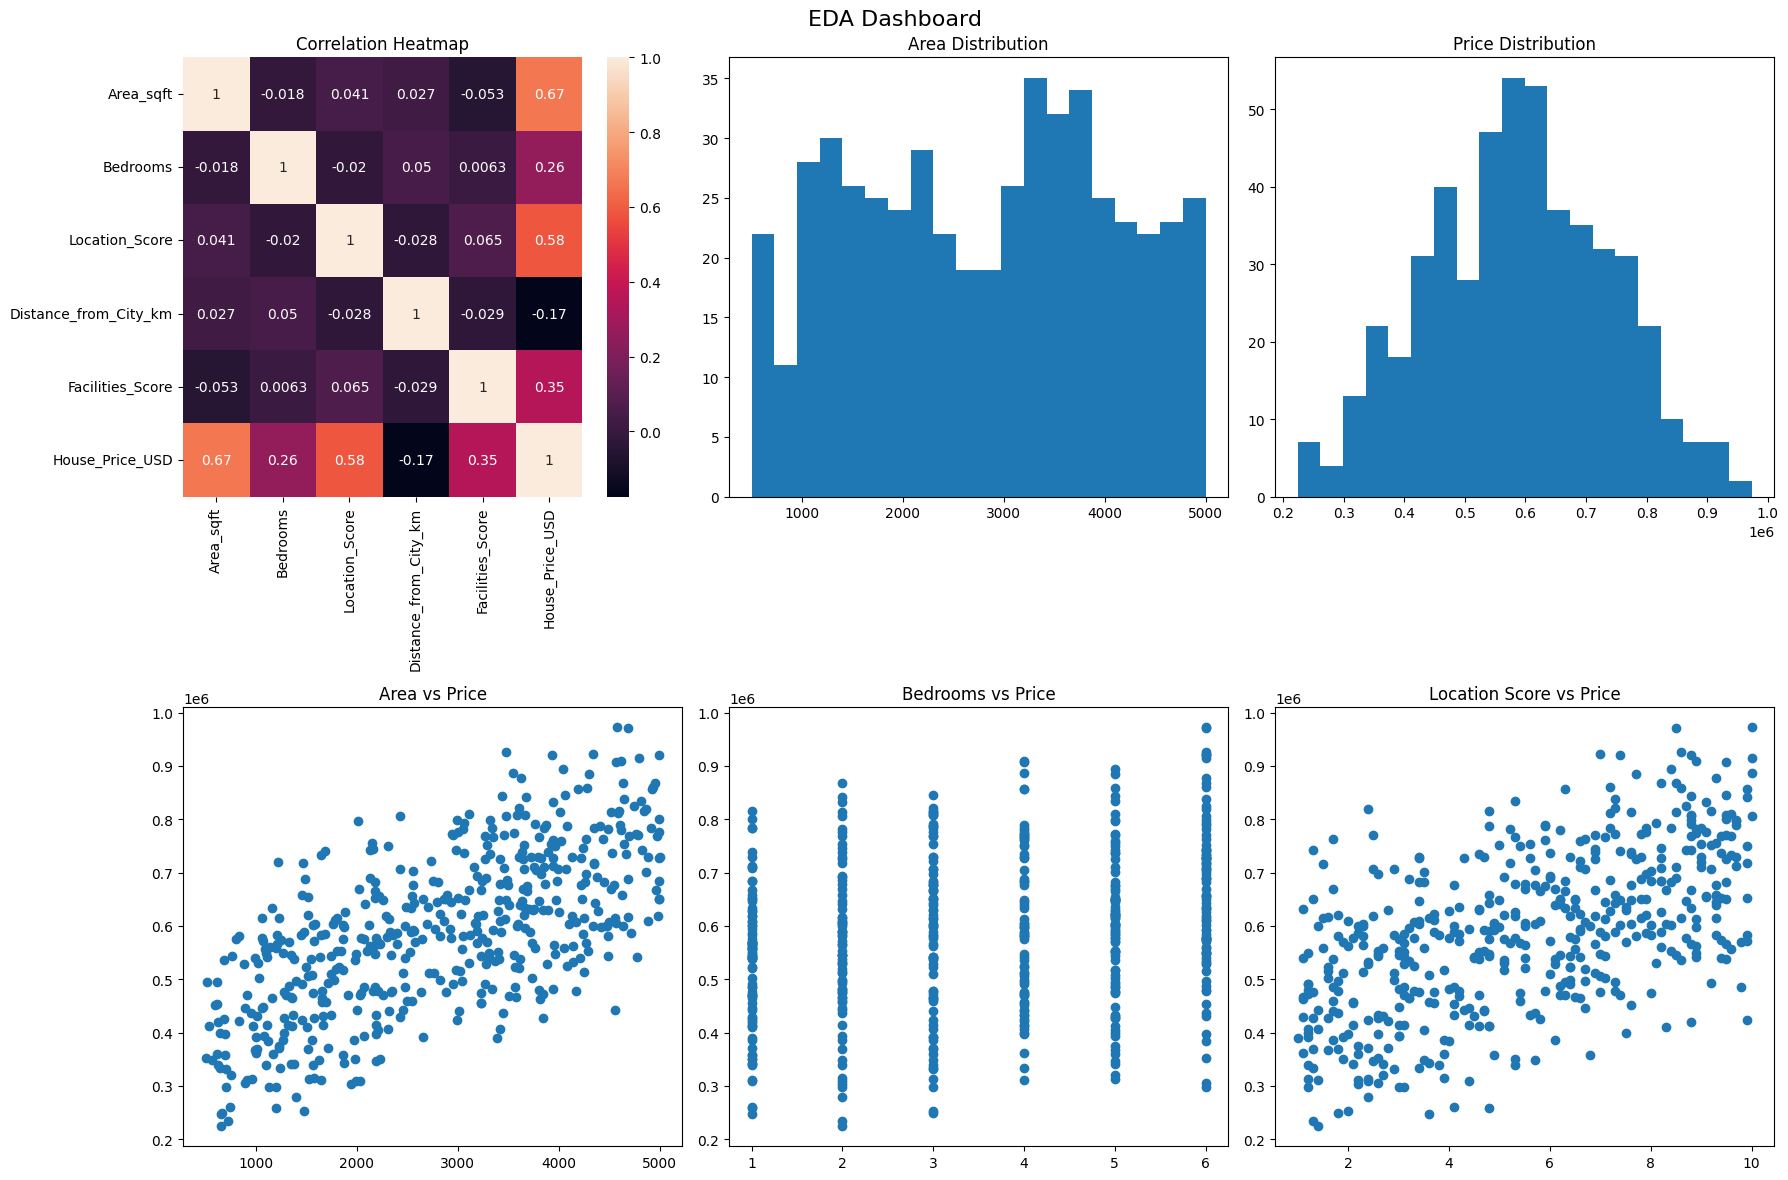


Model trained ✓
Tree depth  : 6
No. of leaves: 63

 DECISION TREE — EVALUATION
MSE  : 4,579,253,112.13
RMSE : 67,670.18
R²   : 0.8143


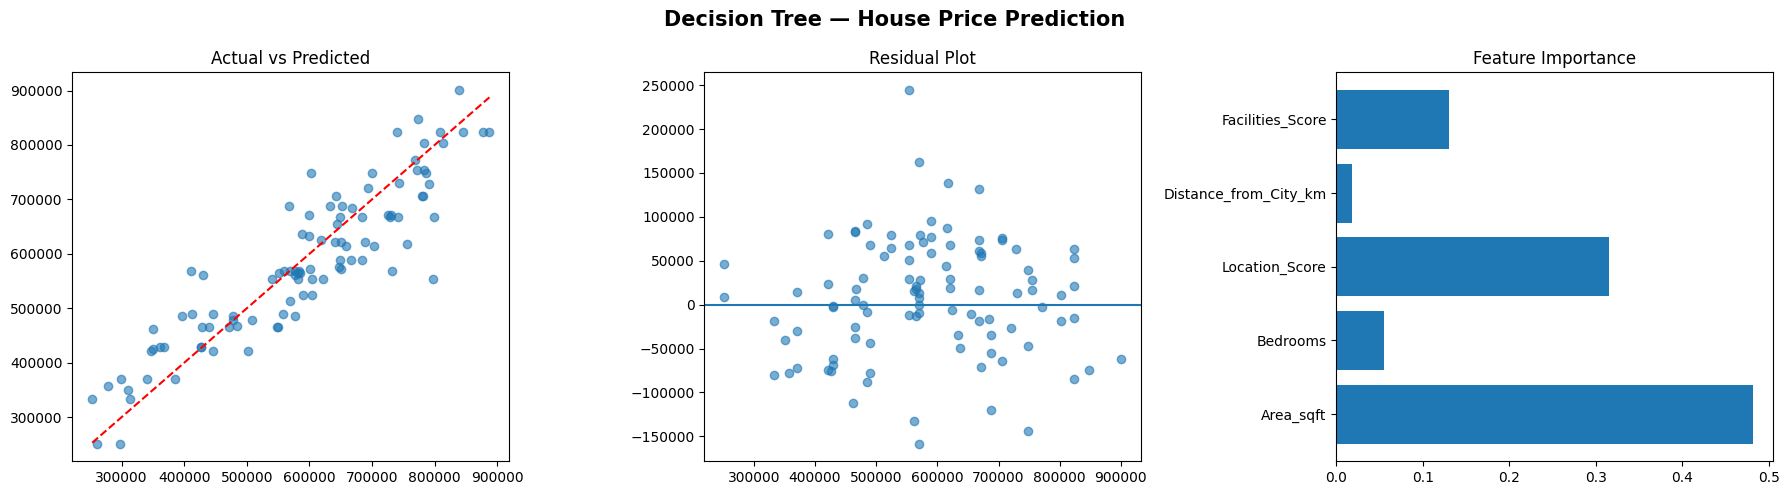

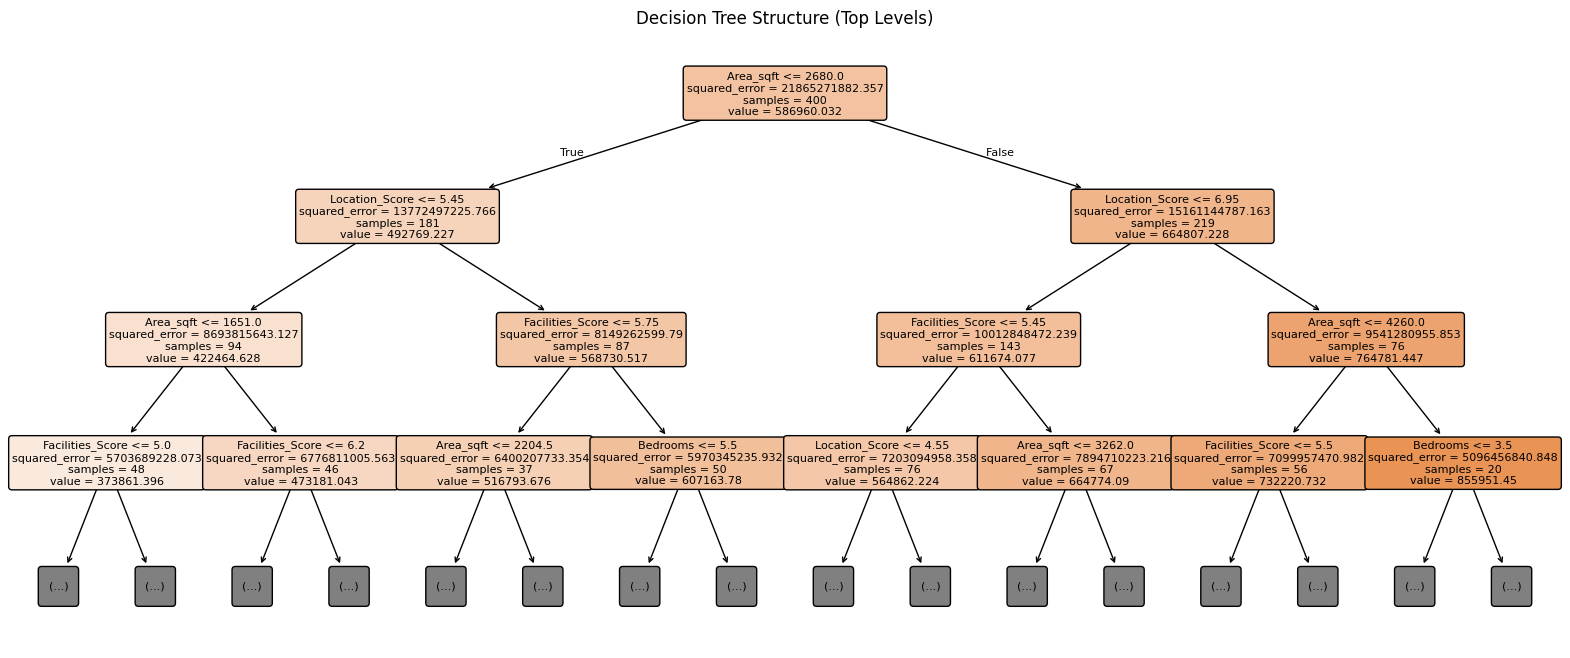

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def generate_dataset(n_samples=500, random_seed=42):
    np.random.seed(random_seed)

    area               = np.random.randint(500, 5001, n_samples)
    bedrooms           = np.random.randint(1, 7, n_samples)
    location_score     = np.round(np.random.uniform(1, 10, n_samples), 1)
    distance_from_city = np.round(np.random.uniform(1, 50, n_samples), 1)
    facilities_score   = np.round(np.random.uniform(1, 10, n_samples), 1)

    noise = np.random.normal(0, 15000, n_samples)

    house_price = (
          area * 80
        + bedrooms * 25000
        + location_score * 30000
        - distance_from_city * 2000
        + facilities_score * 20000
        + 50000
        + noise
    ).astype(int)

    house_price = np.clip(house_price, 50000, 2000000)

    return pd.DataFrame({
        "Area_sqft": area,
        "Bedrooms": bedrooms,
        "Location_Score": location_score,
        "Distance_from_City_km": distance_from_city,
        "Facilities_Score": facilities_score,
        "House_Price_USD": house_price
    })

df = generate_dataset()

print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nDataset Info:")
df.info()
print("\nStatistical Summary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")

plt.subplot(2, 3, 2)
plt.hist(df['Area_sqft'], bins=20)
plt.title("Area Distribution")

plt.subplot(2, 3, 3)
plt.hist(df['House_Price_USD'], bins=20)
plt.title("Price Distribution")

plt.subplot(2, 3, 4)
plt.scatter(df['Area_sqft'], df['House_Price_USD'])
plt.title("Area vs Price")

plt.subplot(2, 3, 5)
plt.scatter(df['Bedrooms'], df['House_Price_USD'])
plt.title("Bedrooms vs Price")

plt.subplot(2, 3, 6)
plt.scatter(df['Location_Score'], df['House_Price_USD'])
plt.title("Location Score vs Price")

plt.suptitle("EDA Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

X = df.drop('House_Price_USD', axis=1)
y = df['House_Price_USD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeRegressor(max_depth=6, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained ✓")
print(f"Tree depth  : {model.get_depth()}")
print(f"No. of leaves: {model.get_n_leaves()}")

y_pred = model.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred)

print("\n" + "="*45)
print(" DECISION TREE — EVALUATION")
print("="*45)
print(f"MSE  : {mse_dt:,.2f}")
print(f"RMSE : {rmse_dt:,.2f}")
print(f"R²   : {r2_dt:.4f}")
print("="*45)

importances = model.feature_importances_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Decision Tree — House Price Prediction', fontsize=15, fontweight='bold')

axes[0].scatter(y_test, y_pred, alpha=0.6)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--')
axes[0].set_title("Actual vs Predicted")

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6)
axes[1].axhline(0)
axes[1].set_title("Residual Plot")

axes[2].barh(X.columns, importances)
axes[2].set_title("Feature Importance")

plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 8))
plot_tree(
    model,
    max_depth=3,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure (Top Levels)")
plt.show()